Find repo root, data dir and plots dir

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

NOTEBOOK_DIR = Path.cwd()
def find_repo_root(start_path: Path):
    current = start_path
    for _ in range(10): 
        if (current / ".git").exists() or (current / "data").exists():
            return current
        current = current.parent
    return start_path

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
DATA_DIR = REPO_ROOT / "data" / "processed/Processed_FFT"
PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR)
print("Repo root    :", REPO_ROOT)
print("Data dir     :", DATA_DIR)
print("Plots dir    :", PLOTS_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Notebook dir: E:\A1_last_version\notebooks\modeling
Repo root    : E:\A1_last_version
Data dir     : E:\A1_last_version\data\processed\Processed_FFT
Plots dir    : E:\A1_last_version\plots
Device: cuda


This part is to check and make sure we got the right Data from FFT and double check the Data has the same shape

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

data_train = np.load(DATA_DIR / "data_train.npy")
data_test  = np.load(DATA_DIR / "data_test.npy")

label_train_18 = np.load(DATA_DIR / "label_train_18.npy")
label_test_18  = np.load(DATA_DIR / "label_test_18.npy")

label_train_bin = np.load(DATA_DIR / "label_train_binary.npy")
label_test_bin  = np.load(DATA_DIR / "label_test_binary.npy")

gesture_classes = np.load(DATA_DIR / "gesture_classes.npy", allow_pickle=True)

print("data_train shape:", data_train.shape)
print("data_test  shape:", data_test.shape)
print("label_train_18 shape:", label_train_18.shape, "unique:", len(np.unique(label_train_18)))
print("label_test_18  shape:", label_test_18.shape,  "unique:", len(np.unique(label_test_18)))
print("label_train_bin shape:", label_train_bin.shape, "unique:", np.unique(label_train_bin))
print("label_test_bin  shape:", label_test_bin.shape,  "unique:", np.unique(label_test_bin))

print("\nClasses (18):")
print(list(gesture_classes))

data_train shape: (5959, 10624)
data_test  shape: (1629, 10624)
label_train_18 shape: (5959,) unique: 18
label_test_18  shape: (1629,) unique: 18
label_train_bin shape: (5959,) unique: [0 1]
label_test_bin  shape: (1629,) unique: [0 1]

Classes (18):
['Above ear - pull hair', 'Cheek - pinch skin', 'Drink from bottle/cup', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Feel around in tray and pull out an object', 'Forehead - pull hairline', 'Forehead - scratch', 'Glasses on/off', 'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin', 'Pull air toward your face', 'Scratch knee/leg skin', 'Text on phone', 'Wave hello', 'Write name in air', 'Write name on leg']


Build a dataset and dataLoader

In [3]:
class NPYDataset (Dataset):
    def __init__(self, data, label18, labelBin):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.label18 = torch.tensor(label18, dtype=torch.long)  
        self.labelBin = torch.tensor(labelBin, dtype=torch.float32)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx], self.label18[idx], self.labelBin[idx]
    
#Setup a batchsize = 256 
BATCH_SIZE = 256
train_dataset = NPYDataset(data_train, label_train_18, label_train_bin)
test_dataset  = NPYDataset(data_test,  label_test_18,  label_test_bin)

train_Loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_Loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_Loader))
print("Test batches :", len(test_Loader))

Train batches: 24
Test batches : 7


Define a MLP Model

In [4]:
class FFT_MLP(nn.Module):
    def __init__(self, input_dim, num_classes=18):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) 
        )
        
    def forward(self, x):
        return self.net(x)
input_dim = data_train.shape[1]
num_classes = 18
model = FFT_MLP(input_dim=input_dim, num_classes=num_classes).to(device)
print(model)
    

FFT_MLP(
  (net): Sequential(
    (0): Linear(in_features=10624, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=18, bias=True)
  )
)


This part is to define the label which is the requirement 18 to 9, this is the step before evaluate marco F1

In [5]:
for i, c in enumerate(gesture_classes):
    print(i, c)
BFRB_CLASS_INDICES = [0, 1, 3, 4, 6, 7, 9, 10]
bfrb_map = {orig: new for new, orig in enumerate(BFRB_CLASS_INDICES)}  

def convert_18_to_9_array(labels_18):
    labels_9 = np.empty_like(labels_18)
    for i, y in enumerate(labels_18):
        if int(y) in bfrb_map:
            labels_9[i] = bfrb_map[int(y)]   
        else:
            labels_9[i] = 8               
    return labels_9

def evaluate(model, loader, device, verbose=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_count = 0

    all_true_18 = []
    all_pred_18 = []
    all_logits = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) >= 2:
                inputs = batch[0]
                labels_18 = batch[1]
            else:
                raise ValueError("Loader batch format unexpected.")

            inputs = inputs.to(device)
            labels_18 = labels_18.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels_18)

            bs = inputs.size(0)
            total_loss += loss.item() * bs
            total_count += bs

            preds_18 = torch.argmax(logits, dim=1)

            all_true_18.append(labels_18.cpu().numpy())
            all_pred_18.append(preds_18.cpu().numpy())
            all_logits.append(logits.cpu().numpy())

    avg_loss = total_loss / max(total_count, 1)

    label_true_18 = np.concatenate(all_true_18).astype(int)
    label_pred_18 = np.concatenate(all_pred_18).astype(int)
    logits_all = np.concatenate(all_logits, axis=0)
    probs_all = torch.softmax(torch.tensor(logits_all), dim=1).numpy()
    label_true_bin = np.isin(label_true_18, BFRB_CLASS_INDICES).astype(int)
    label_pred_bin = np.isin(label_pred_18, BFRB_CLASS_INDICES).astype(int)
    binary_f1 = f1_score(label_true_bin, label_pred_bin, average="binary", pos_label=1)

    label_true_9 = convert_18_to_9_array(label_true_18)
    label_pred_9 = convert_18_to_9_array(label_pred_18)
    macro_f1_9 = f1_score(label_true_9, label_pred_9, average="macro")

    if verbose:
        print(f"Evaluation Done | Loss: {avg_loss:.4f} | Binary F1: {binary_f1:.4f} | Macro F1 (9-class): {macro_f1_9:.4f}")

    return avg_loss, binary_f1, macro_f1_9, label_true_18, label_pred_18,logits_all, probs_all


0 Above ear - pull hair
1 Cheek - pinch skin
2 Drink from bottle/cup
3 Eyebrow - pull hair
4 Eyelash - pull hair
5 Feel around in tray and pull out an object
6 Forehead - pull hairline
7 Forehead - scratch
8 Glasses on/off
9 Neck - pinch skin
10 Neck - scratch
11 Pinch knee/leg skin
12 Pull air toward your face
13 Scratch knee/leg skin
14 Text on phone
15 Wave hello
16 Write name in air
17 Write name on leg


This the the train part of the model, seed 42, learning rate 0.001, 20 times training.

In [6]:
LR = 0.001
EPOCHS = 20

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
test_acc_list = []
train_losses = []
test_losses = []
test_f1_bin_list = []
test_f1_macro9_list = []
for epoch in range(1, EPOCHS + 1):
    num_batches = 0
    model.train()
    running_loss = 0.0
    total = 0
    all_true_18 = []
    all_pred_18 = []
    for data, label18, labelBin in train_Loader:
        num_batches += 1
        data = data.to(device)
        label18 = label18.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, label18)
        loss.backward()
        optimizer.step()

        bs = data.size(0)
        running_loss += loss.item() * bs
        total += bs

    train_loss = running_loss / max(total, 1)
    test_loss, f1_bin, f1_macro9, y_true_18, y_pred_18, _, _ = evaluate(model, test_Loader, device)
    correct = (y_true_18 == y_pred_18).sum()
    acc = correct / max(len(y_true_18), 1)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_f1_bin_list.append(f1_bin)
    test_f1_macro9_list.append(f1_macro9)
    test_acc_list.append(float(acc))
    print("epoch", epoch, "total samples:", total, "num_batches:", num_batches)
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | "
          f"acc={acc:.4f} | "
          f"binary_f1={f1_bin:.4f} | macro_f1(9c)={f1_macro9:.4f}")

epoch 1 total samples: 5959 num_batches: 24
Epoch 01/20 | train_loss=3.5665 | test_loss=2.6154 | acc=0.1725 | binary_f1=0.7927 | macro_f1(9c)=0.1802
epoch 2 total samples: 5959 num_batches: 24
Epoch 02/20 | train_loss=2.4624 | test_loss=2.3604 | acc=0.2480 | binary_f1=0.7967 | macro_f1(9c)=0.2619
epoch 3 total samples: 5959 num_batches: 24
Epoch 03/20 | train_loss=2.2203 | test_loss=2.3157 | acc=0.2382 | binary_f1=0.8244 | macro_f1(9c)=0.2550
epoch 4 total samples: 5959 num_batches: 24
Epoch 04/20 | train_loss=2.0330 | test_loss=2.1006 | acc=0.2996 | binary_f1=0.8468 | macro_f1(9c)=0.3166
epoch 5 total samples: 5959 num_batches: 24
Epoch 05/20 | train_loss=1.8450 | test_loss=2.0394 | acc=0.3450 | binary_f1=0.8316 | macro_f1(9c)=0.3238
epoch 6 total samples: 5959 num_batches: 24
Epoch 06/20 | train_loss=1.7328 | test_loss=1.9773 | acc=0.3585 | binary_f1=0.8709 | macro_f1(9c)=0.3557
epoch 7 total samples: 5959 num_batches: 24
Epoch 07/20 | train_loss=1.6135 | test_loss=2.0987 | acc=0.311

This part is to save the model to artifacts, the purpes is to make sure the model is reproductable

In [7]:
import json, time

ART_DIR = REPO_ROOT / "artifacts" / "fft_mlp_all" 
RESULT_DIR = REPO_ROOT / "results"
SUMMARY_DIR = RESULT_DIR / "Model1_Training"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

final_test_loss, final_f1_bin, final_f1_macro9, y_true_18, y_pred_18, y_logits, y_prob = evaluate(
    model, test_Loader, device, verbose=True
)

# Saved prediction (late fusion）
np.save(ART_DIR / "y_true_18.npy", y_true_18)
np.save(ART_DIR / "y_pred_18.npy", y_pred_18)
np.save(ART_DIR / "y_logits.npy", y_logits)   
np.save(ART_DIR / "y_prob.npy", y_prob)      

# saved train losses and test losses
np.save(ART_DIR / "train_losses.npy", np.array(train_losses))
np.save(ART_DIR / "test_losses.npy", np.array(test_losses))
np.save(ART_DIR / "test_f1_bin.npy", np.array(test_f1_bin_list))
np.save(ART_DIR / "test_f1_macro9.npy", np.array(test_f1_macro9_list))

# saved metrics.json
metrics = {
    "seed": SEED,
    "epochs": EPOCHS,
    "lr": LR,
    "batch_size": BATCH_SIZE,
    "input_dim": int(input_dim),
    "num_classes": int(num_classes),
    "final_test_loss": float(final_test_loss),
    "final_binary_f1": float(final_f1_bin),
    "final_macro_f1_9class": float(final_f1_macro9),
    "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}
with open(ART_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

# saved models：weights + checkpoint
torch.save(model.state_dict(), ART_DIR / "model_weights.pt")

torch.save({
    "epoch": EPOCHS,
    "model_state": model.state_dict(),
    "optim_state": optimizer.state_dict(),
    "train_losses": train_losses,
    "test_losses": test_losses,
    "seed": SEED,
    "input_dim": input_dim,
    "num_classes": num_classes,
}, ART_DIR / "checkpoint.pt")
summary = {
    "final_metrics": {
        "acc": float(test_acc_list[-1]),
        "macroF1": float(test_f1_macro9_list[-1]),
        "binaryF1": float(test_f1_bin_list[-1])
    }
}
print("Saved everything to:", ART_DIR)
summary_path = SUMMARY_DIR / "model1_training_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)
print("Final metrics:", summary["final_metrics"])


Evaluation Done | Loss: 1.9581 | Binary F1: 0.9027 | Macro F1 (9-class): 0.3901
Saved everything to: E:\A1_last_version\artifacts\fft_mlp_all
Saved: E:\A1_last_version\results\Model1_Training\model1_training_summary.json
Final metrics: {'acc': 0.4045426642111725, 'macroF1': 0.3901452270186474, 'binaryF1': 0.902738432483475}


This part is to produce the plot for the model to show the loss of train and test

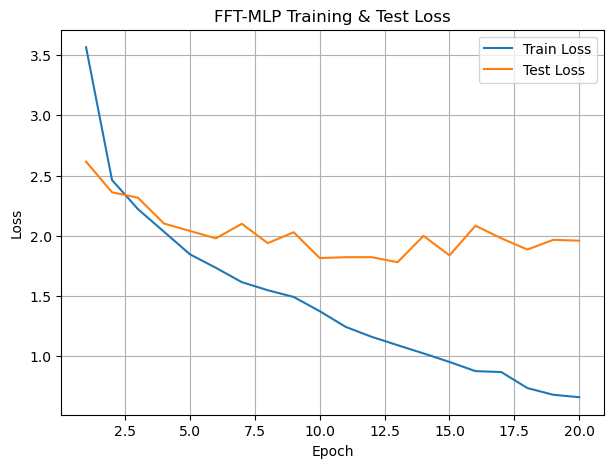

Saved: E:\A1_last_version\plots\fft_mlp_all\loss_curve.png


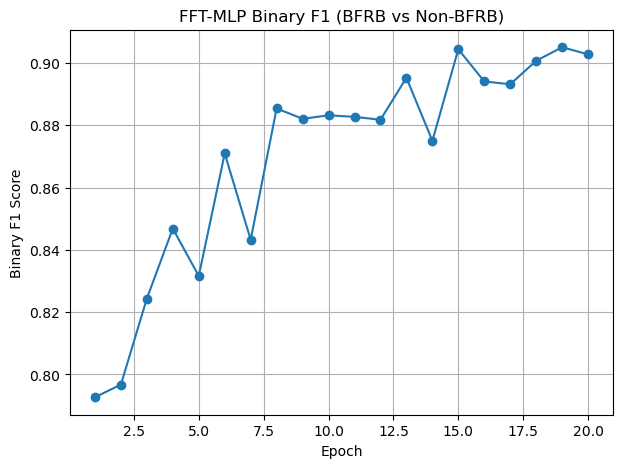

Saved: E:\A1_last_version\plots\fft_mlp_all\binary_f1_curve.png


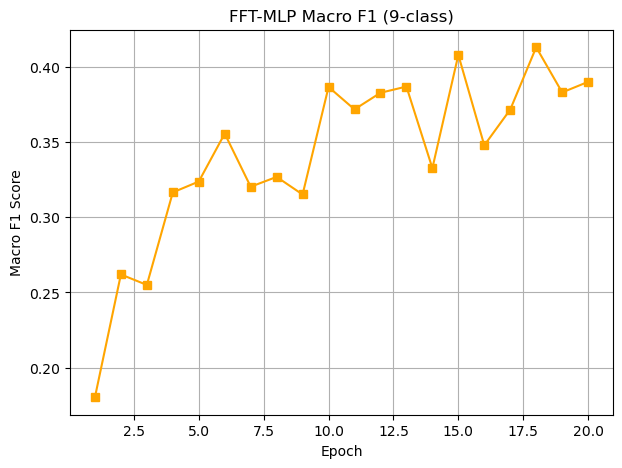

Saved: E:\A1_last_version\plots\fft_mlp_all\macro_f1_9class_curve.png


In [8]:
# =========================
# Plot 1: Loss Curve
# =========================
import matplotlib.pyplot as plt

FFT_PLOT_DIR = PLOTS_DIR / "fft_mlp_all"
FFT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FFT-MLP Training & Test Loss")
plt.legend()
plt.grid(True)

loss_path = FFT_PLOT_DIR / "loss_curve.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", loss_path)
# =========================
# Plot 2: Binary F1 Curve
# =========================
plt.figure(figsize=(7,5))
plt.plot(epochs, test_f1_bin_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Binary F1 Score")
plt.title("FFT-MLP Binary F1 (BFRB vs Non-BFRB)")
plt.grid(True)

binf1_path = FFT_PLOT_DIR / "binary_f1_curve.png"
plt.savefig(binf1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", binf1_path)
# =========================
# Plot 3: Macro F1 (9-class)
# =========================
plt.figure(figsize=(7,5))
plt.plot(epochs, test_f1_macro9_list, marker="s", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("FFT-MLP Macro F1 (9-class)")
plt.grid(True)

macro9_path = FFT_PLOT_DIR / "macro_f1_9class_curve.png"
plt.savefig(macro9_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", macro9_path)
